# Kalshi market making with sports data feeds: final report (Parts 1–6)

This notebook rebuilds every main model from the raw data and reproduces the results of the per-part notebooks. All functions live in `final_code/`:
- `starter.py` and `mm_core.py` are the provided helpers, unchanged.
- `p1_mid` … `p6_market` hold one module per part.

**Rules followed throughout** (DATA.md / code/README.md)
- **Split by match:** test = scheduled start ≥ Sep 15 00:00 UTC (`test_match_ids`). Every hyperparameter, threshold and model choice is made on **train**; every reported number is **test**.
- **Clocks:** feeds are timed only by `t_recv_ns` (when they reached us). Provider clocks (`date`, `stime`, `state_ts_ms`) are used only to measure delay, never for ordering.
- **Real-time rows only:** BETER incidents `msg_type == 1`, Sportradar `feedtype == "delta"`. CS2 `Killing` is not used. BETER prices use de-margined `p1`, never odds.
- **One axis per match:** `trades_on_axis`, with dir = +1 when the taker bought team 1 / home.
- **No look-ahead:** a decision at t uses prints stamped ≤ t − 0.1 s (`visible_index` latency), touch rows received ≤ t, and feed rows received ≤ t − 0.1 s.
- **Touch:** only `book_ok` events. As a target or a quoting input, the touch counts as known only if its last change is ≤ 5 s old and it isn't locked or crossed.
- **Settlement:** void (scalar) matches are dropped before any settlement mark. All standard errors and t-statistics are **clustered by match**.

**Stated compromise.** The Part 3/4 event windows (120 s) and the Part 5/6 P&L marks accept a touch up to **30 s** old. Requiring ≤ 5 s at every point of an event window keeps only 5% of CS2 events, because quiet books legitimately sit unchanged for more than 5 s. The cost of this choice is checked against the strict 5 s rule in Parts 3 and 6.

In [1]:
import sys, os, json, warnings; sys.path.insert(0, "final_code"); warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from starter import D, test_match_ids
import p1_mid as p1, p2_feed as p2, p3_leadlag as p3, p4_latency as p4, p5_forecast as p5, p6_market as p6
GR, OUT = "graphs/final", "output/final"; os.makedirs(GR, exist_ok=True); os.makedirs(OUT, exist_ok=True)
SPORTS = ("CS2", "MLB")
pd.set_option("display.max_colwidth", 90)

## Part 1: a midpoint from prints

**Target:** the recorded Kalshi touch mid at t, on a 1 s grid of in-play seconds in `book_ok` matches, with the touch fresh (≤ 5 s) and uncrossed. It's the price a maker quotes against. Scoring against the last print would reward chasing the last aggressor.

**Estimators:** the tape mid (last print − dir × 1c), an EWMA, a VWAP, and the last-n tape-implied spread (Model 5), plus a Lasso correction on causal tape features.
- **CS2 winner, Model 3b:** tape mid + Lasso (EWMA / VWAP gaps, activity, imbalance, staleness, dir × implied spread).
- **MLB winner, Model 6:** Model 5 + Lasso (per-trade EWMA gap, implied spread). MLB spreads are one tick, which the fixed 1c tape-mid shift overcorrects.

**Choices on train:** every window or weight by train RMSE; the Lasso penalty by match-grouped CV with the 1-SE rule; c = median train print size.

In [2]:
P1, P1_TUNE, BOARD, G1 = {}, {}, [], {}
for s in SPORTS:
    tr, bb, test = p1.part1_data(s)
    P1[s], Gtr, Gte, P1_TUNE[s] = p1.fit_part1(s, tr, bb, test)
    for est in ("tape_mid", "ewma", "vwap", "lastn_mid", "winner"):
        BOARD.append({"sport": s, "estimator": {"winner": "Model 3b" if s == "CS2" else "Model 6", "lastn_mid": "Model 5 (last-n spread)"}.get(est, est),
                      **p1.score(Gte, est)})
    G1[s] = Gte[["match_id", "mid", "tape_mid", "winner"]]
    del tr, bb, Gtr, Gte
BOARD = pd.DataFrame(BOARD).set_index(["sport", "estimator"])
assert abs(BOARD.loc[("CS2", "Model 3b"), "RMSE_c"] - 1.9002) < 5e-4 and abs(BOARD.loc[("MLB", "Model 6"), "RMSE_c"] - 0.3763) < 5e-4
print("chosen on TRAIN:", {s: {k: (round(v, 3) if isinstance(v, float) else v) for k, v in P1[s].items() if k in ("H", "W", "n_last", "c")}
                          | ({"alpha": P1[s]["lasso6"]["alpha"]} if s == "MLB" else {}) for s in SPORTS})
BOARD[["RMSE_c", "RMSE_se_c", "bias_c", "bias_se_c", "matches", "points"]].round(4)

chosen on TRAIN: {'CS2': {'H': 0.2, 'W': 0.2, 'n_last': 1, 'c': 10.0}, 'MLB': {'H': 0.3, 'W': 0.0, 'n_last': 1, 'c': 20.51, 'alpha': 0.3}}


RMSE_c  RMSE_se_c  bias_c  bias_se_c  matches  \
sport estimator                                                                
CS2   tape_mid                 1.9518     0.1021 -0.0248     0.0429       28   
      ewma                     1.9347     0.1141 -0.0334     0.0440       28   
      vwap                     1.9989     0.1108 -0.0288     0.0437       28   
      Model 5 (last-n spread)  2.2421     0.1185 -0.0101     0.0559       28   
      Model 3b                 1.9002     0.1089 -0.0078     0.0432       28   
MLB   tape_mid                 0.6327     0.0106  0.0267     0.0139       31   
      ewma                     0.5801     0.0114  0.0247     0.0131       31   
      vwap                     0.6277     0.0101  0.0265     0.0136       31   
      Model 5 (last-n spread)  0.4133     0.0158  0.0157     0.0081       31   
      Model 6                  0.3763     0.0140  0.0273     0.0084       31   

                               points  
sport estimator                        
CS2   tape_mid                 159824  
      ewma                     159824  
      vwap                     159824  
      Model 5 (last-n spread)  159824  
      Model 3b                 159824  
MLB   tape_mid                 270953  
      ewma                     270953  
      vwap                     270953  
      Model 5 (last-n spread)  270953  
      Model 6                  270953

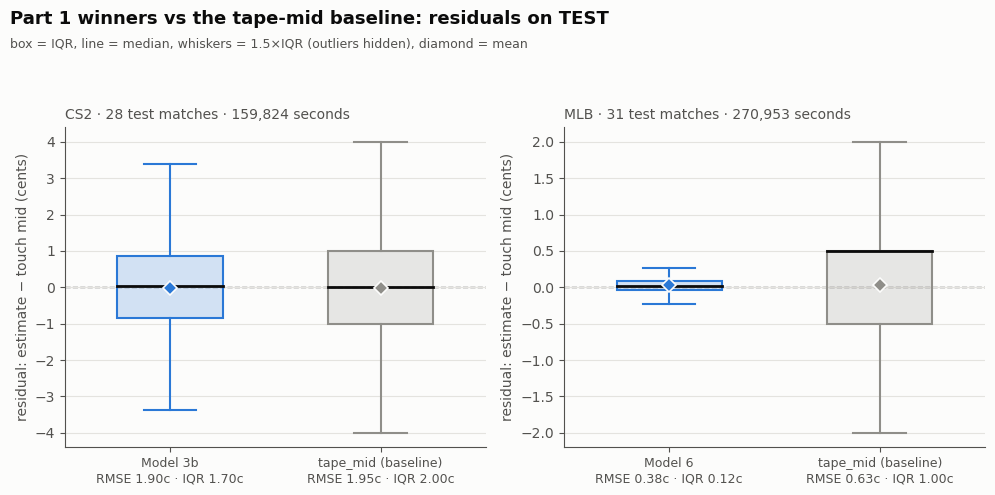

In [3]:
p1.residual_figure([("CS2", G1["CS2"], [("Model 3b", "winner", "#2a78d6"), ("tape_mid (baseline)", "tape_mid", "#8f8e89")]),
                    ("MLB", G1["MLB"], [("Model 6", "winner", "#2a78d6"), ("tape_mid (baseline)", "tape_mid", "#8f8e89")])], f"{GR}/p1_residuals.png")

**Result (test):**
- **CS2:** Model 3b 1.900c RMSE vs 1.952c for the tape mid, a small gain.
- **MLB:** Model 6 0.376c vs 0.633c. Most of the gain comes from fixing the tape mid's 1c over-shift on one-tick spreads.
- Both are unbiased.

These two estimators are "our mid" in every later part.

## Part 2: is the feed a fair value?

- **Feeds:** CS2 BETER's live match-winner probability; MLB a win-probability model we built from Sportradar game state.
- **Comparison:** each feed vs our Part 1 mid on a 1 s in-play grid, using every mapped match where the feed is live. Because the touch is only the *target*, matches without a book still enter the comparison of bias and slope.
- **Blend:** mid + w·(feed − mid), with w fitted on train (closed-form least squares against the touch mid) and scored on test.
- **"When to stop trusting it":** w is refitted on train *within* each condition, and the % change in test RMSE is shown with a match-bootstrap CI.

**Key decisions**
- **Price levels** are binned on (feed + mid)/2, so the binning doesn't favor either side.
- **MLB win probability:** a structural win expectancy (run distributions fitted on train) with an XGBoost correction boosted from logit(we), monotone in we and the score. Depth and number of trees are chosen by grouped CV log loss on train.
- **Game state** is rebuilt from real-time delta rows only; base occupancy is carried forward from the last "Play over".

**Compromise:** the MLB model has no team-strength or pitcher information, so its *level* is about 9c from the market. That decides the MLB blend.

,bias_c,bias_se_c,RMSE_c,slope,slope_se,matches,seconds
train,-0.018,0.187,4.116,1.000,0.006,120.0,711114.0
test,-0.279,0.307,4.621,0.972,0.011,37.0,222325.0


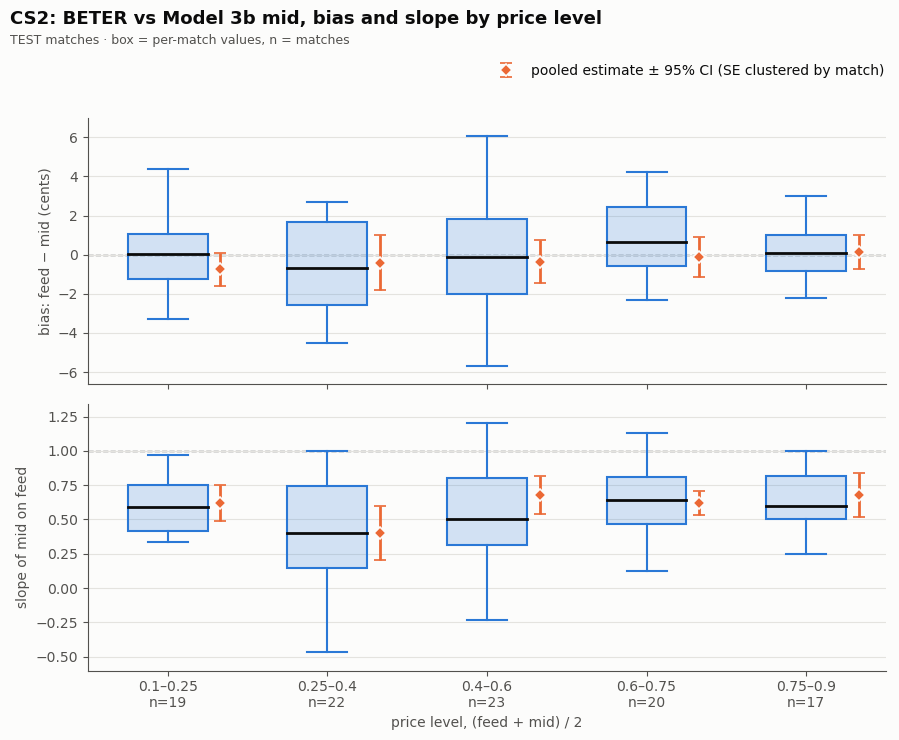

In [4]:
CTX = {s: p3.sport_context(s, P1[s]) for s in SPORTS}        # all mapped in-play prints + Part 1 estimators, book_ok touch
cs2_ids = set(pd.read_parquet(D + "map_esports.parquet").query("sport_id == 3").beter_match_id)
TEST = {"CS2": test_match_ids("esports") & cs2_ids, "MLB": test_match_ids("mlb")}
Cg = p2.cs2_comparison_grid(CTX["CS2"]["tr"], CTX["CS2"]["bb"], P1["CS2"], TEST["CS2"])
display(pd.DataFrame({"train": p2.compare(Cg[~Cg.test]), "test": p2.compare(Cg[Cg.test])}).T.round(3))
Cg["level_label"] = p2.level_labels(Cg)
p2.bias_slope_figure(Cg, "level_label", "CS2: BETER vs Model 3b mid, bias and slope by price level", "price level, (feed + mid) / 2",
                     f"{GR}/p2_cs2_bias_slope_level.png", "TEST matches · box = per-match values, n = matches")

,w_train,w_train_se,train_matches,test_RMSE_mid_c,test_RMSE_blend_c,test_RMSE_feed_c,gain_c2,gain_se_c2,gain_t,w_test_refit,w_test_se,test_matches,test_seconds
target,,,,,,,,,,,,,
touch now,0.1748,0.0233,54,1.9312,1.7803,4.1055,0.5600,0.1311,4.2730,0.1684,0.0252,26,117152
touch +30 s,0.2925,0.0240,54,3.4427,3.2624,4.6530,1.2092,0.2501,4.8353,0.2512,0.0276,26,117300
touch +120 s,0.4161,0.0350,54,6.0029,5.7782,6.4180,2.6473,0.6387,4.1446,0.3693,0.0407,26,117226


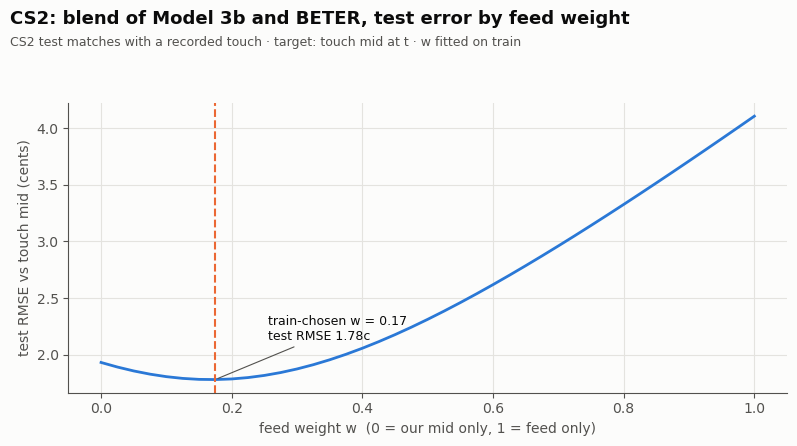

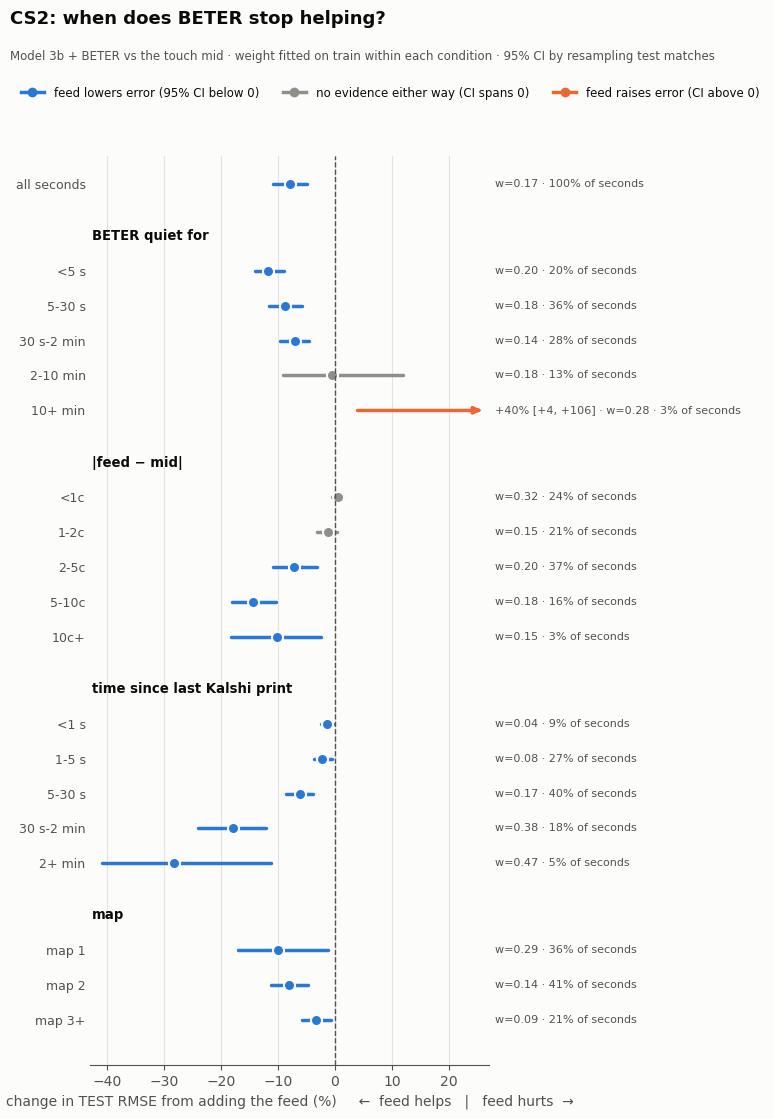

In [5]:
BL_CS2 = p2.blend_table(Cg); assert abs(BL_CS2.loc["touch now", "w_train"] - 0.1748) < 5e-4
display(BL_CS2.round(4))
p2.weight_curve_figure(Cg, BL_CS2.loc["touch now", "w_train"], f"{GR}/p2_cs2_blend.png", "CS2: blend of Model 3b and BETER, test error by feed weight",
                       "CS2 test matches with a recorded touch · target: touch mid at t · w fitted on train")
FT_CS2 = p2.forest_table(Cg, p2.CS2_TRUST_GROUPS)
p2.forest_figure(FT_CS2, p2.CS2_TRUST_GROUPS, f"{GR}/p2_cs2_trust.png", "CS2: when does BETER stop helping?",
                 "Model 3b + BETER vs the touch mid · weight fitted on train within each condition · 95% CI by resampling test matches")

win-probability model chosen by grouped CV on TRAIN: {'max_depth': 1.0, 'min_child_weight': 20.0, 'n_estimators': 25.0, 'cv_logloss': 0.4439313513388018}


,bias_c,bias_se_c,RMSE_c,slope,slope_se,matches,seconds
train,0.823,0.570,6.082,1.025,0.010,63.0,595121.0
test,4.038,1.001,9.182,0.992,0.024,31.0,319602.0


,w_train,w_train_se,train_matches,test_RMSE_mid_c,test_RMSE_blend_c,test_RMSE_feed_c,gain_c2,gain_se_c2,gain_t,w_test_refit,w_test_se,test_matches,test_seconds
target,,,,,,,,,,,,,
touch now,0.0018,0.0007,62,0.3763,0.3765,9.2867,-0.0002,0.0001,-1.2949,0.0003,0.0004,31,270953
touch +30 s,0.0056,0.0052,62,2.7533,2.7534,9.6631,-0.0007,0.0035,-0.1914,0.0021,0.0036,31,270930
touch +120 s,0.0085,0.0174,62,5.6546,5.6560,10.9033,-0.0156,0.0207,-0.7537,-0.0065,0.0138,31,270587


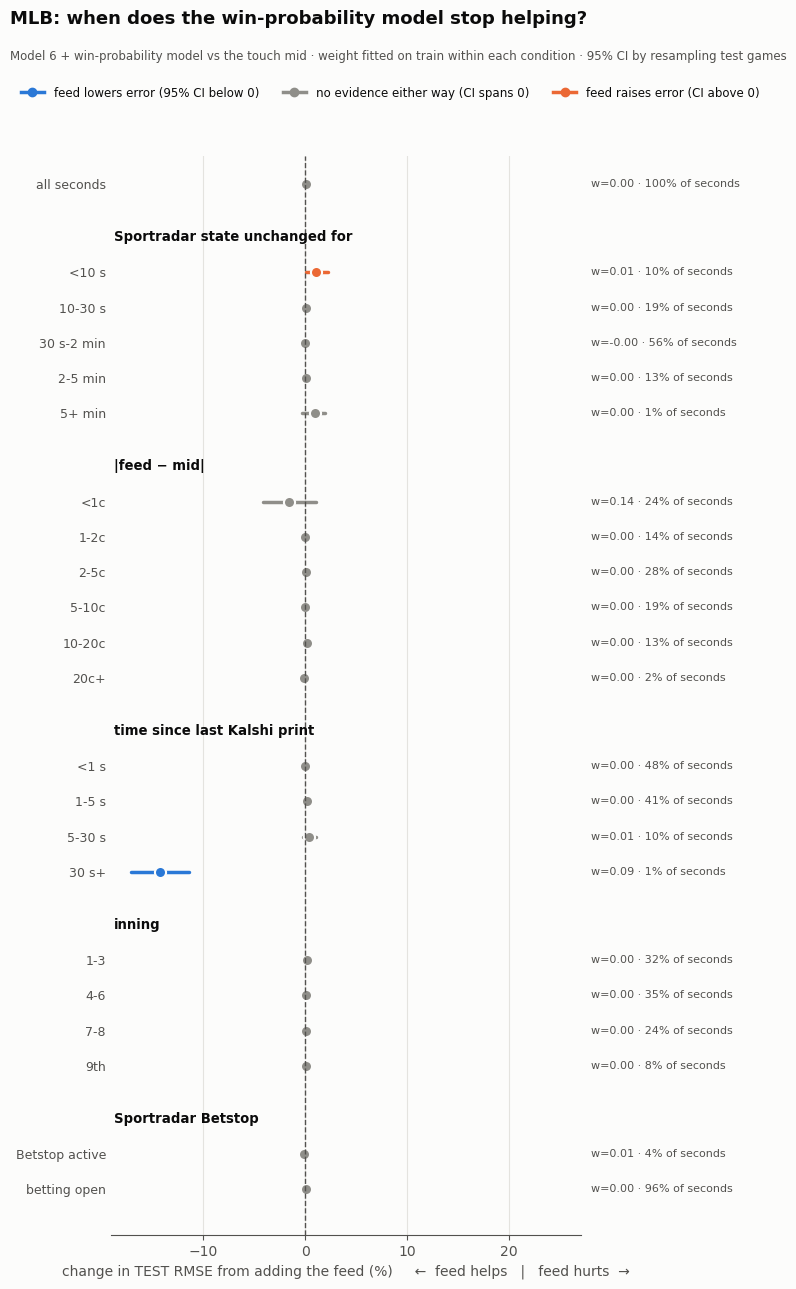

In [6]:
EV = pd.read_parquet(D + "sportradar_mlb_events.parquet")
mlb_ids = set(pd.read_parquet(D + "map_mlb.parquet").sr_match_id)
S, WP_MODEL, WP_CV = p2.fit_wp_model(EV, mlb_ids, TEST["MLB"])
print("win-probability model chosen by grouped CV on TRAIN:", WP_CV.iloc[0].to_dict())
Mg = p2.mlb_comparison_grid(CTX["MLB"]["tr"], CTX["MLB"]["bb"], P1["MLB"], S, EV, TEST["MLB"])
display(pd.DataFrame({"train": p2.compare(Mg[~Mg.test]), "test": p2.compare(Mg[Mg.test])}).T.round(3))
BL_MLB = p2.blend_table(Mg); assert abs(BL_MLB.loc["touch now", "w_train"] - 0.0018) < 5e-4
display(BL_MLB.round(4))
FT_MLB = p2.forest_table(Mg, p2.MLB_TRUST_GROUPS)
p2.forest_figure(FT_MLB, p2.MLB_TRUST_GROUPS, f"{GR}/p2_mlb_trust.png", "MLB: when does the win-probability model stop helping?",
                 "Model 6 + win-probability model vs the touch mid · weight fitted on train within each condition · 95% CI by resampling test games")
del Cg, Mg

**Result (test):**
- **CS2:** BETER earns a blend weight of **0.17** and cuts test RMSE by about **8%** (gain t ≈ 4). It helps most when the Kalshi tape is stale.
- **MLB:** the win-probability model earns **w ≈ 0.002** and doesn't help. It knows the game state but not who is better, so the market (a one-tick touch) already beats it.

## Part 3: who knows first? The lead/lag map

For each feed feature we run an event study aligned on the moment **we received** the event:
- **Fraction of the eventual move already done,** in the tape (Part 1 mid) and in the touch.
- **Share of taker contracts trading with the move,** in 2 s bins.
- **The same curve on the provider's own clock,** to separate network delay from the provider's entry delay.

**Key decisions**
- **Direction comes from the feed, never from Kalshi's move:**
  - the BETER move's sign; the round winner; the scoring team; the batting team for Betstop;
  - the change in win expectancy over the play, for pitch release and ball in play. That's hindsight, so those two measure *reaction timing*, not information in the message.

  Signing by Kalshi's own move would make every curve rise mechanically.
- **Pooling:** the fraction is a ratio of sums over events; CIs come from a match bootstrap.
- **Lead:** t½, the time the touch had done half the move (< 0 means Kalshi was first).
- **Chosen on train:** window ±60 s (curves level off by +60 s), BETER jumps of 3c or more (similar at 2c and 5c), 10 s de-clustering. Unconditional and before-a-run Betstops are both reported.

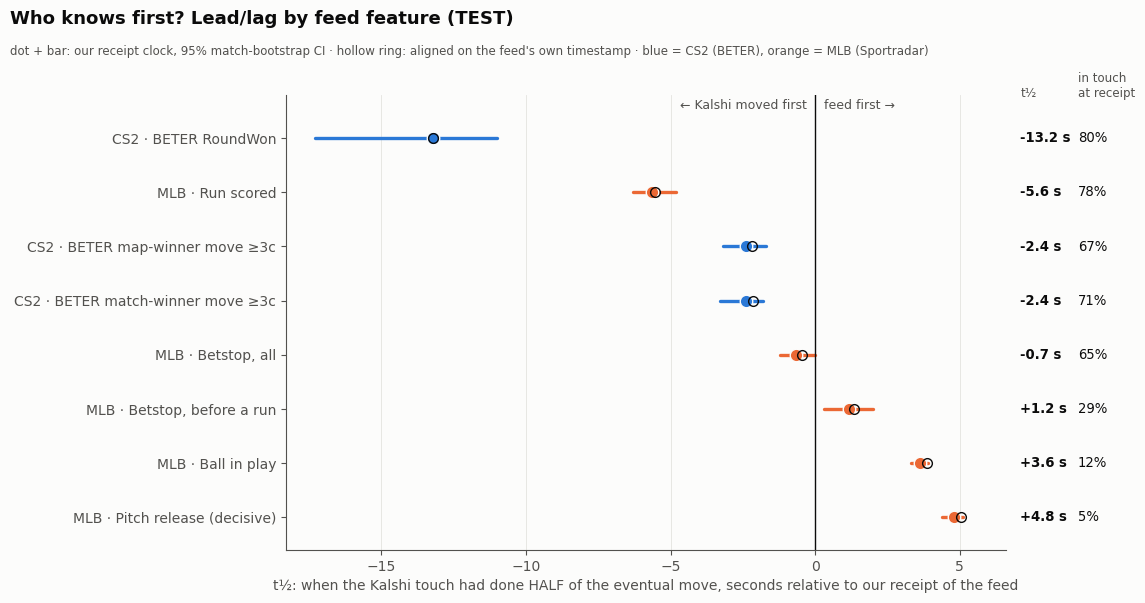

,sport,feature,kalshi_lead_s,t_half_touch_s,t_half_ci,t_half_TRAIN,in_touch_at_0,in_tape_at_0,takers_with_10s_before,takers_with_10s_after,move_c,events,matches,t_half_touch_feed_clock_s,net_delay_med_s
0,CS2,BETER RoundWon,13.23,-13.23,"[-17.3, -11.0]",-12.35,0.80,0.65,0.62,0.63,4.21,1148,27,-13.20,0.21
1,MLB,Run scored,5.63,-5.63,"[-6.3, -4.8]",-4.73,0.78,0.75,0.82,0.42,11.08,206,31,-5.54,0.20
2,CS2,BETER map-winner move ≥3c,2.40,-2.40,"[-3.2, -1.7]",-1.53,0.67,0.32,0.61,0.46,2.41,1180,24,-2.17,0.23
3,CS2,BETER match-winner move ≥3c,2.39,-2.39,"[-3.3, -1.8]",-1.58,0.71,0.42,0.69,0.51,3.68,698,24,-2.16,0.24
4,MLB,"Betstop, all",0.66,-0.66,"[-1.2, +0.0]",-0.37,0.65,0.62,0.60,0.55,1.39,1163,31,-0.47,0.20
5,MLB,"Betstop, before a run",-1.17,1.17,"[+0.3, +2.0]",0.99,0.29,0.28,0.82,0.62,10.93,206,31,1.33,0.21
6,MLB,Ball in play,-3.63,3.63,"[+3.3, +3.9]",3.10,0.12,0.11,0.65,0.61,4.14,1384,31,3.86,0.23
7,MLB,Pitch release (decisive),-4.81,4.81,"[+4.4, +5.1]",4.56,0.05,0.06,0.57,0.70,3.69,2113,31,5.06,0.21


In [7]:
W, H, THETA = 60, 60, 0.03
WE = S[["match_id", "t_recv_ns", "we"]]
def events(split):
    c, m = CTX["CS2"][split], CTX["MLB"][split]
    E = p3.mlb_feature_events(EV, m, WE)
    return {("CS2", "BETER match-winner move ≥3c"): p3.beter_jumps(c, "match", THETA), ("CS2", "BETER map-winner move ≥3c"): p3.beter_jumps(c, "map", THETA),
            ("CS2", "BETER RoundWon"): p3.round_won(c), ("MLB", "Pitch release (decisive)"): E["pitch"], ("MLB", "Ball in play"): E["bip"],
            ("MLB", "Betstop, before a run"): E["betstop_run"], ("MLB", "Betstop, all"): E["betstop_all"], ("MLB", "Run scored"): E["run"]}
EV3 = {sp: events(sp) for sp in ("train", "test")}
RES3 = {sp: {k: p3.study(e, CTX[k[0]], W, H) for k, e in EV3[sp].items()} for sp in ("test", "train")}
LEAD = p3.lead_table(RES3["test"], RES3["train"]).rename(columns={"t_half_touch_TRAIN_s": "t_half_TRAIN"})
LEAD.to_csv(f"{OUT}/p3_lead_table.csv", index=False)
p3.ranking_figure(LEAD, f"{GR}/p3_lead_ranking.png"); plt.show()
LEAD[["sport", "feature", "kalshi_lead_s", "t_half_touch_s", "t_half_ci", "t_half_TRAIN", "in_touch_at_0", "in_tape_at_0",
      "takers_with_10s_before", "takers_with_10s_after", "move_c", "events", "matches", "t_half_touch_feed_clock_s", "net_delay_med_s"]].round(2)

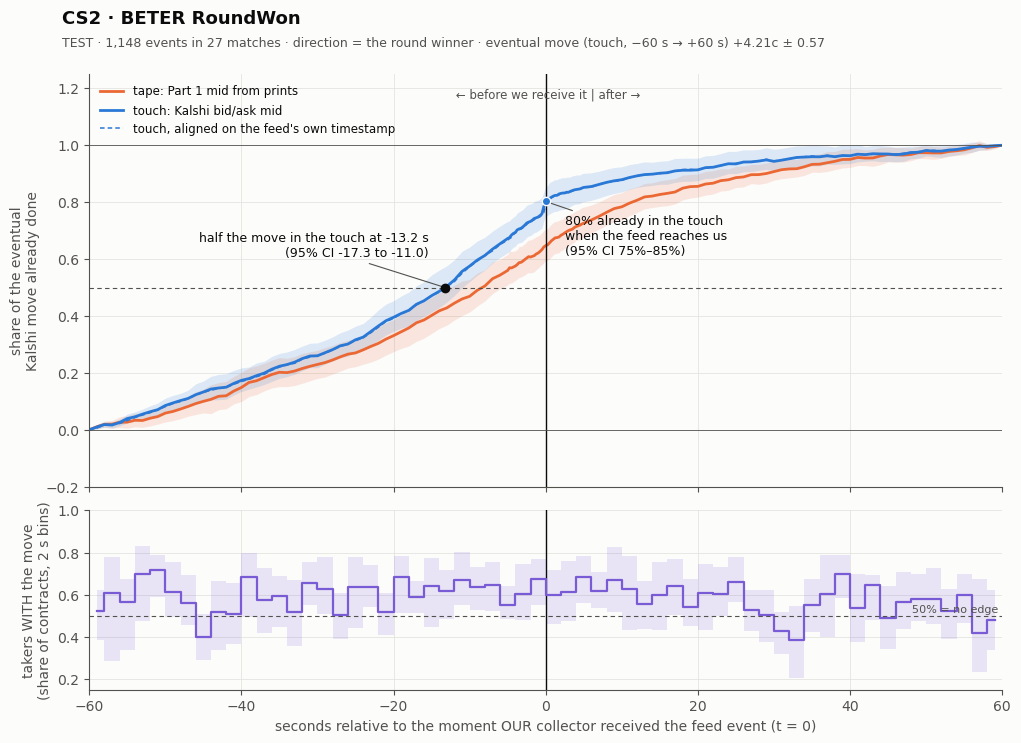

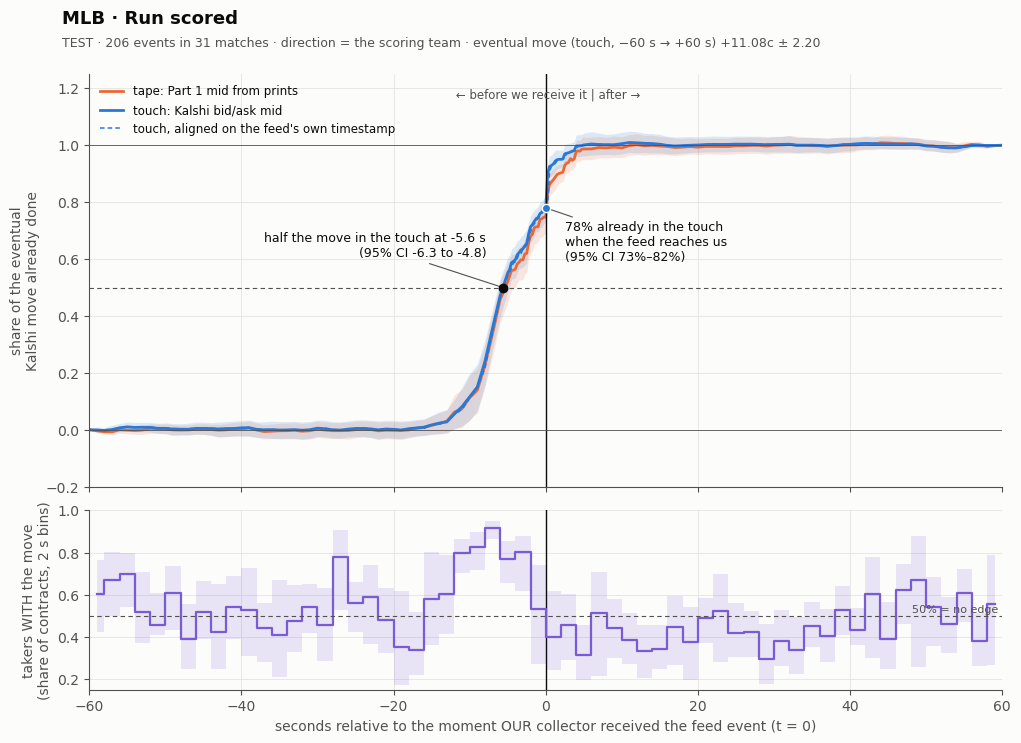

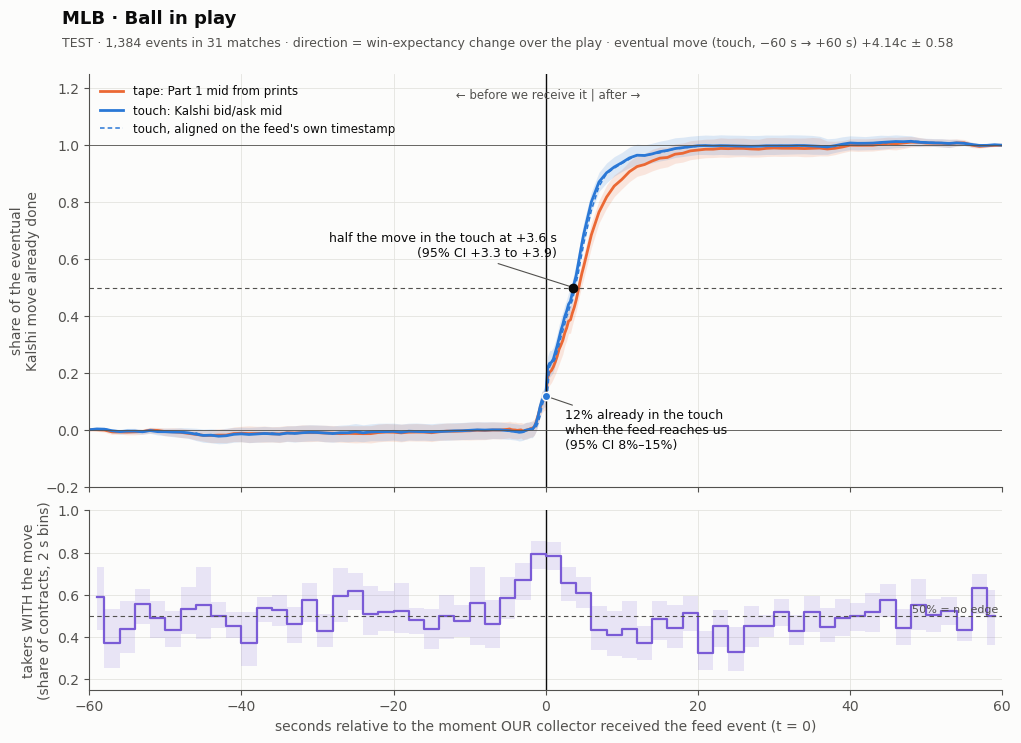

In [8]:
for key, direction in [(("CS2", "BETER RoundWon"), "the round winner"), (("MLB", "Run scored"), "the scoring team"),
                       (("MLB", "Ball in play"), "win-expectancy change over the play")]:
    slug = "".join(ch if ch.isalnum() else "_" for ch in f"{key[0]}_{key[1]}").lower()
    p3.feature_figure(RES3["test"][key], f"{key[0]} · {key[1]}", direction, f"{GR}/p3_{slug}.png"); plt.show()

In [9]:
# robustness to the stated compromise: MLB event study with the strict 5 s touch-staleness rule
rows = []
ctx5 = dict(CTX["MLB"], touch_fn=lambda m, t: p3.touch_mid_at(CTX["MLB"]["bb"], m, t, max_stale_s=5.0))
for key in [k for k in EV3["test"] if k[0] == "MLB"]:
    r5 = p3.study(EV3["test"][key], ctx5, W, H, B=300)["recv"]; r = RES3["test"][key]["recv"]
    rows.append({"feature": key[1], "t½ (≤30 s touch)": r["touch"]["t_half"], "t½ (≤5 s touch)": r5["touch"]["t_half"],
                 "in touch at 0 (≤30 s)": r["touch"]["F0"], "in touch at 0 (≤5 s)": r5["touch"]["F0"], "events (≤30 s)": r["events"], "events (≤5 s)": r5["events"]})
pd.DataFrame(rows).round(2)

,feature,t½ (≤30 s touch),t½ (≤5 s touch),in touch at 0 (≤30 s),in touch at 0 (≤5 s),events (≤30 s),events (≤5 s)
0,Pitch release (decisive),4.81,4.51,0.05,0.05,2113,1348
1,Ball in play,3.63,3.48,0.12,0.14,1384,860
2,"Betstop, before a run",1.17,1.11,0.29,0.29,206,134
3,"Betstop, all",-0.66,-0.60,0.65,0.61,1163,710
4,Run scored,-5.63,-5.63,0.78,0.78,206,134


**Result (test).** Kalshi is ahead on every **outcome** message:
- BETER RoundWon: t½ −13 s, 80% priced on arrival;
- MLB run scored: −5.6 s, 78% priced;
- BETER's match and map prices: −2.4 s.

Takers trade with the move *before* those messages arrive (61–82% of contracts).

Sportradar's **process** messages arrive *before* the market moves:
- Betstop before a run: +1.2 s;
- ball in play: +3.6 s;
- decisive pitch release: +4.8 s.

Re-aligning on the provider's own clock moves every curve by only about the **0.2 s network delay**; the rest of each gap is the provider's entry delay. Under the strict 5 s touch rule the MLB t½ values move by 0.3 s or less, with about 35–40% fewer events.

*(Ball in play and pitch release differ from `part3.ipynb` by 0.03 s. This notebook uses one win-expectancy model, fitted on all train games, for Parts 2, 3 and 5.)*

## Part 4: normalize for latency

**Simulation:** every feed timestamp moves k s earlier (`asof(..., shift_s=k)` for the blend; `t_recv_ns − k` for the events), for k from 0 to 10 s. The Kalshi side is untouched.

**Definitions**
- **A feature stops lagging** when t½(k) ≥ 0, i.e. the shifted message arrives before the touch is half done.
- **The blend weight stops rising** at the k where the train weight peaks, with a CI from a **paired** match bootstrap (the same matches at every k).

**Plausibility** is judged against the measured network delay (provider stamp → us).

network delay (our receipt − provider stamp), median 0.213 s


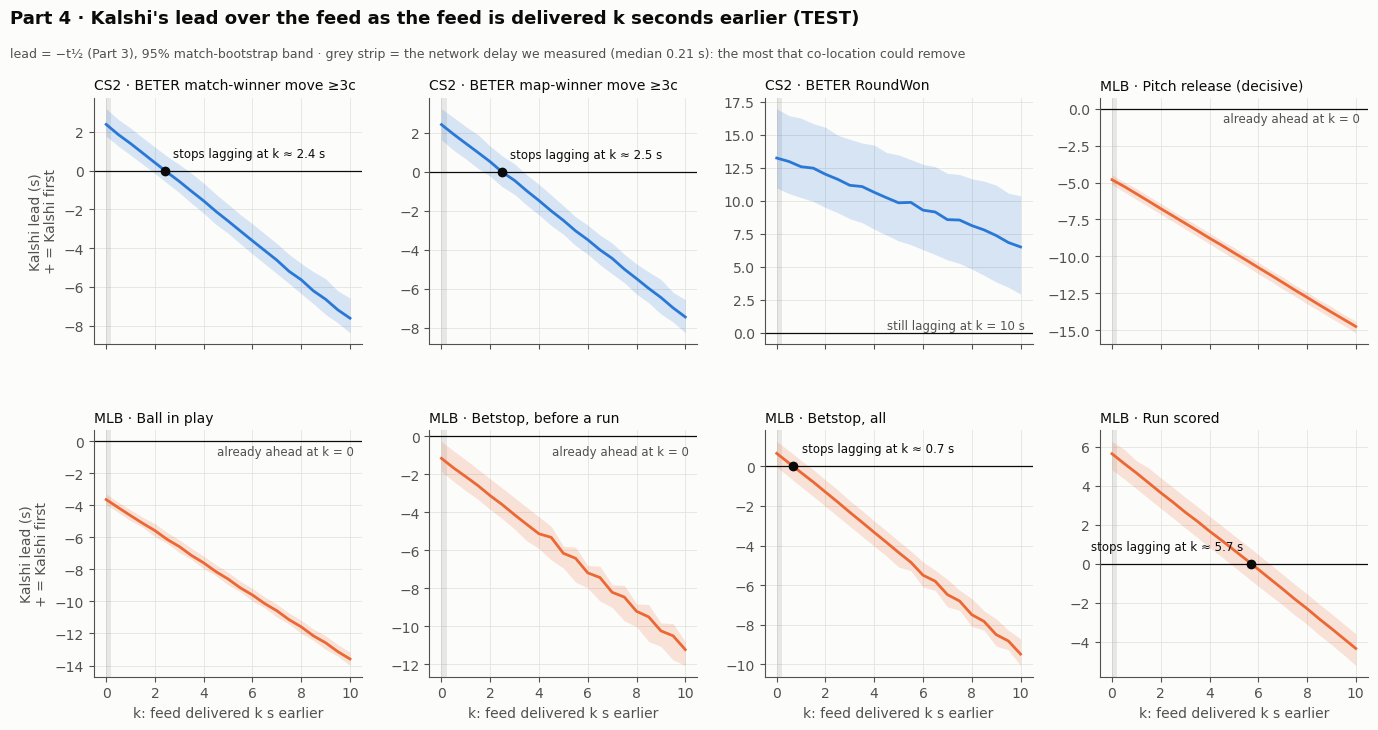

,sport,feature,t_half_at_k0_s,k_stop_lagging,k_lo,k_hi,k_10pct
0,CS2,BETER RoundWon,-13.23,NaN,NaN,NaN,NaN
1,MLB,Run scored,-5.63,5.71,4.85,6.46,NaN
2,CS2,BETER map-winner move ≥3c,-2.40,2.47,1.70,3.35,NaN
3,CS2,BETER match-winner move ≥3c,-2.39,2.42,1.85,3.34,NaN
4,MLB,"Betstop, all",-0.66,0.68,0.00,1.33,NaN
5,MLB,Pitch release (decisive),4.81,0.00,0.00,0.00,0.00
6,MLB,Ball in play,3.63,0.00,0.00,0.00,0.52
7,MLB,"Betstop, before a run",1.17,0.00,0.00,0.00,1.43


In [10]:
KS3 = np.arange(0, 10.01, 0.5)
LK = {key: pd.DataFrame([p4.lead_at_k(e, CTX[key[0]], k) for k in KS3]) for key, e in EV3["test"].items()}
KN = {key: p4.k_needed(L) for key, L in LK.items()}
NET = float(pd.concat([(e.t_recv_ns - e.t_prov_ns) / 1e9 for e in EV3["test"].values()]).median())
print(f"network delay (our receipt − provider stamp), median {NET:.3f} s")
p4.lead_vs_k_figure(LK, KN, NET, f"{GR}/p4_lead_vs_k.png"); plt.show()
KT = pd.DataFrame([{"sport": k[0], "feature": k[1], "t_half_at_k0_s": LK[k].t_half.iloc[0], **KN[k]} for k in LK])
KT = KT.sort_values("k_stop_lagging", ascending=False, na_position="first").reset_index(drop=True); KT.to_csv(f"{OUT}/p4_k_needed.csv", index=False)
KT.round(2)

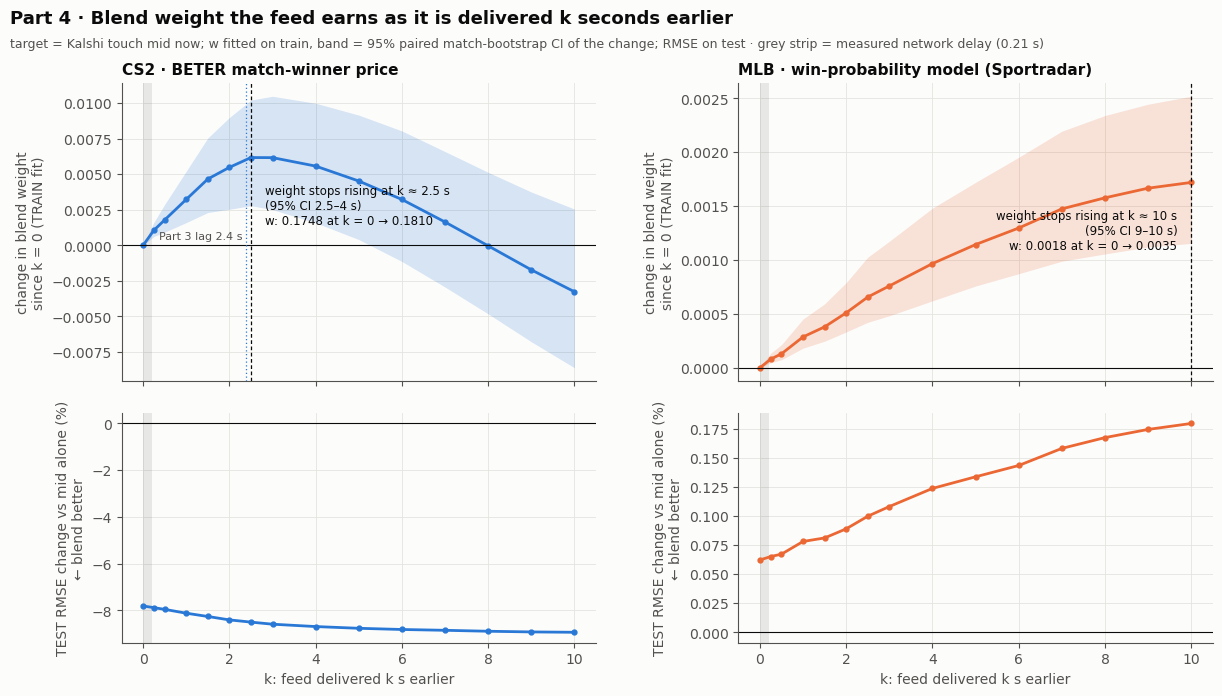

,k_peak,k_peak_lo,k_peak_hi,w_at_0,w_peak,rise,rise_lo,rise_hi
CS2 · BETER match-winner price,2.5,2.5,4.0,0.1748,0.1810,0.0062,0.0028,0.0105
MLB · win-probability model (Sportradar),10.0,9.0,10.0,0.0018,0.0035,0.0017,0.0012,0.0025


In [11]:
KS = [0, 0.25, 0.5, 1, 1.5, 2, 2.5, 3, 4, 5, 6, 7, 8, 9, 10]
G4 = {"CS2": p4.cs2_grid(CTX["CS2"], P1["CS2"]), "MLB": p4.mlb_grid(CTX["MLB"], P1["MLB"])}
shift = {"CS2 · BETER match-winner price": lambda k: p4.feed_at_k(G4["CS2"], p4.cs2_feed(), k, "p1", keep=lambda f: (f.st1 == 1).values),
         "MLB · win-probability model (Sportradar)": lambda k: p4.feed_at_k(G4["MLB"], S[["match_id", "t_recv_ns", "wp"]], k, "wp")}
BK, PK = {}, {}
for name, fn in shift.items():
    BK[name], PK[name] = p4.blend_curve({k: fn(k) for k in KS}, TEST["CS2"] if name.startswith("CS2") else TEST["MLB"])
assert abs(BK["CS2 · BETER match-winner price"].w_train.iloc[0] - 0.1748) < 5e-4
lags = {"CS2 · BETER match-winner price": -LEAD.loc[LEAD.feature == "BETER match-winner move ≥3c", "t_half_touch_s"].item()}
p4.blend_vs_k_figure(BK, PK, lags, NET, f"{GR}/p4_blend_vs_k.png"); plt.show()
del G4
pd.DataFrame(PK).T.round(4)

**Result:** k needed to stop lagging:
- **BETER prices: 2.4–2.5 s**, and the CS2 blend weight peaks at the same **2.5 s**. The gain is small, because BETER's value is its level, not its speed.
- **MLB runs: 5.7 s.**
- **RoundWon:** never within 10 s. The round is priced while it's being played.
- **Process messages:** 0, already ahead.

The network delay (about 0.2 s) is all that hosting can remove.

**Shifts carried into Parts 5–6:**
- **CS2 k = 2.5 s:** plausible with a faster provider, and it creates no look-ahead.
- **MLB k = 0.2 s:** the network delay. A 5.7 s shift would move pitch release, ball in play and Betstop into the future.

## Part 5: predict the move, then CANCEL and TAKE

**Target:** the change in the touch mid over the next 10 s and 30 s. **No feature contains the touch mid**, so "feed − mid" uses the *tape* mid; otherwise the bid/ask bounce would sit on both sides and fake a high R².

**Features,** all causal:
- **tape:** signed taker flow over 2–120 s, print intensity, momentum;
- **touch:** spread, queue imbalance, touch age;
- **feed:** BETER gap (+ staleness interaction), jumps, rounds; MLB win-probability changes, runs, Betstop, taker flow after the last ball in play or pitch;
- **context:** distance from 0/1, time in game;
- **game state:** map, score, inning, plus late / close / near-50% flags and signal × state interactions.

**Models:** **Lasso** with the penalty at the grouped-CV minimum on train. The 1-SE rule zeroed every feature, because a few volatile matches make the fold-to-fold spread larger than the whole signal.
- **Direction** (signed move) drives TAKE and skew.
- **Size** (|move|) drives CANCEL.
- **Model choice:** the richer variant is used only if it wins train grouped-CV R² at **both** horizons.
- **Two fits:** feed as received, and feed earlier by the Part 4 k.

**Rules**
- **CANCEL:** an always-on maker (tape mid ∓ h, `mm_core.simulate_maker`, optimistic and strict fills) pulls quotes when the size forecast > x. x is the most volume that still breaks even on train.
- **TAKE:** cross when |direction forecast| > half-spread + 0.07·p·(1−p).

In [12]:
K = {"CS2": 2.5, "MLB": 0.2}
G5 = {s: p5.base_grid(CTX[s], P1[s], s) for s in SPORTS}
X5 = {(s, k): p5.feature_table(G5[s], CTX[s], s, k, S=S, ev=EV) for s in SPORTS for k in (0.0, K[s])}
split5 = lambda s, h: (G5[s][f"y{h}"].values, np.isfinite(G5[s][f"y{h}"].values) & ~G5[s].test.values,
                       np.isfinite(G5[s][f"y{h}"].values) & G5[s].test.values, G5[s].match_id.values)
rows, CAND = [], {}
for s in SPORTS:
    dirs, sizes = p5.design_matrices(s, G5[s], X5[(s, 0.0)], S, 0.0)
    for h in (10, 30):
        y, tr_, te_, g = split5(s, h)
        for task, cands, target in (("direction", dirs, y), ("size", sizes, np.abs(y))):
            for name, F in cands.items():
                M = p5.fit_lasso(F[tr_], target[tr_], g[tr_])
                rows.append({"sport": s, "task": task, "model": name, "horizon": h,
                             "train_CV_R2": p5.train_cv_r2(F[tr_], target[tr_], g[tr_], M["alpha"]),
                             "test_R2": p5.r2_boot(target[te_], p5.predict(M, F[te_]), target[tr_].mean(), g[te_])[0]})
CH = pd.DataFrame(rows)
richer = {"direction": "+ game state + signal × state", "size": "activity + game state"}
simpler = {"direction": "no game state", "size": "activity only"}
FINAL5 = {}
for (s, task), d in CH.groupby(["sport", "task"]):
    cv = d.pivot(index="horizon", columns="model", values="train_CV_R2")
    FINAL5[(s, task)] = richer[task] if (cv[richer[task]] > cv[simpler[task]]).all() else simpler[task]
print("chosen on TRAIN:", FINAL5)
assert FINAL5 == {("CS2", "direction"): "no game state", ("CS2", "size"): "activity + game state",
                  ("MLB", "direction"): "+ game state + signal × state", ("MLB", "size"): "activity + game state"}
CH.pivot_table(index=["sport", "task", "model"], columns="horizon", values=["train_CV_R2", "test_R2"]).mul(100).round(2)

chosen on TRAIN: {('CS2', 'direction'): 'no game state', ('CS2', 'size'): 'activity + game state', ('MLB', 'direction'): '+ game state + signal × state', ('MLB', 'size'): 'activity + game state'}


test_R2        train_CV_R2  \
horizon                                            10     30          10   
sport task      model                                                      
CS2   direction + game state + signal × state    3.06   2.57        2.87   
                no game state                    3.07   2.89        2.83   
      size      activity + game state            8.38  11.92       10.77   
                activity only                    6.83   8.41        8.95   
MLB   direction + game state + signal × state    0.53   0.29        0.50   
                no game state                    0.47   0.24        0.40   
      size      activity + game state           16.49  10.86       16.50   
                activity only                   15.26   7.71       14.84   

                                                      
horizon                                           30  
sport task      model                                 
CS2   direction + game state + signal × state   2.48  
                no game state                   2.61  
      size      activity + game state          13.63  
                activity only                   9.67  
MLB   direction + game state + signal × state   0.22  
                no game state                   0.18  
      size      activity + game state          12.01  
                activity only                   7.53

In [13]:
rows, FALL, COEF = [], {}, {}
for s in SPORTS:
    for k in (0.0, K[s]):
        dirs, sizes = p5.design_matrices(s, G5[s], X5[(s, k)], S, k)
        fc = G5[s][["match_id", "t", "mtape", "touch_mid", "test"]].copy()
        for h in (10, 30):
            y, tr_, te_, g = split5(s, h)
            for task, F, target in (("direction", dirs[FINAL5[(s, "direction")]], y), ("size", sizes[FINAL5[(s, "size")]], np.abs(y))):
                M = p5.fit_lasso(F[tr_], target[tr_], g[tr_])
                r2, lo, hi = p5.r2_boot(target[te_], p5.predict(M, F[te_]), target[tr_].mean(), g[te_])
                rows.append({"sport": s, "forecast": task, "fit": "feed as received" if k == 0 else f"feed {k:g} s earlier", "horizon": f"{h} s",
                             "test R² (95% CI)": f"{100*r2:.2f}%  [{100*lo:.2f}, {100*hi:.2f}]"})
                fc[("dir" if task == "direction" else "size") + str(h)] = p5.predict(M, F)
                if k == 0: COEF[(s, task, h)] = p5.lasso_coefs(M)
        FALL.setdefault(s, fc) if k == 0 else None
        if k != 0: FALL[s] = FALL[s].merge(fc[["match_id", "t", "dir10", "dir30", "size10", "size30"]], on=["match_id", "t"], suffixes=("", "_k"))
R2 = pd.DataFrame(rows); R2.to_csv(f"{OUT}/p5_final_r2.csv", index=False)
R2.pivot_table(index=["sport", "forecast", "fit"], columns="horizon", values="test R² (95% CI)", aggfunc="first", sort=False)

horizon                                               10 s  \
sport forecast  fit                                          
CS2   direction feed as received       3.07%  [2.26, 3.84]   
                feed 2.5 s earlier     3.55%  [2.61, 4.52]   
      size      feed as received      8.38%  [5.04, 10.78]   
                feed 2.5 s earlier    8.72%  [5.40, 11.11]   
MLB   direction feed as received       0.53%  [0.30, 0.77]   
                feed 0.2 s earlier     0.49%  [0.30, 0.71]   
      size      feed as received    16.49%  [14.27, 18.68]   
                feed 0.2 s earlier  16.58%  [14.34, 18.78]   

horizon                                              30 s  
sport forecast  fit                                        
CS2   direction feed as received      2.89%  [1.44, 4.46]  
                feed 2.5 s earlier    3.35%  [1.76, 5.13]  
      size      feed as received    11.92%  [5.79, 15.95]  
                feed 2.5 s earlier  12.04%  [5.91, 15.93]  
MLB   direction feed as received      0.29%  [0.21, 0.38]  
                feed 0.2 s earlier    0.29%  [0.21, 0.39]  
      size      feed as received    10.86%  [8.71, 12.96]  
                feed 0.2 s earlier  10.87%  [8.72, 12.97]

In [14]:
# placebo: every direction feature computed 60 s before it could be known (target unchanged) -> R² should be ~0
rows = []
for s in SPORTS:
    Xp = p5.feature_table(G5[s], CTX[s], s, 0.0, lag_s=60.0, S=S, ev=EV)
    Fp = p5.add_state(Xp, G5[s], G5[s].t.values - 60.0, s, S=S)
    cols = p5.base_cols(s) if FINAL5[(s, "direction")] == "no game state" else list(Fp.columns)
    for h in (10, 30):
        y, tr_, te_, g = split5(s, h); M = p5.fit_lasso(Fp[cols][tr_], y[tr_], g[tr_])
        rows.append({"sport": s, "horizon": f"{h} s", "placebo test R²": f"{100 * p5.r2_boot(y[te_], p5.predict(M, Fp[cols][te_]), y[tr_].mean(), g[te_])[0]:.2f}%"})
display(pd.DataFrame(rows).pivot(index="sport", columns="horizon", values="placebo test R²"))
# the largest coefficients of the final models (cents of move, or of |move|, per 1 SD of the feature)
pd.concat({f"{s} {task} {h}s": c[c != 0].head(6).round(3).reset_index().rename(columns={"index": "feature", 0: "coef"}).apply(
    lambda r: f"{r.feature} {r.coef:+.3f}", axis=1).reset_index(drop=True) for (s, task, h), c in COEF.items()}, axis=1).fillna("")

horizon,10 s,30 s
sport,,
CS2,-0.01%,0.00%
MLB,0.00%,0.00%


,CS2 direction 10s,CS2 size 10s,CS2 direction 30s,CS2 size 30s,MLB direction 10s,MLB size 10s,MLB direction 30s,MLB size 30s
0,feed_gap_c +0.330,spread_c +0.170,feed_gap_c +0.685,round_diff -0.445,flow_since_bip_x_close +0.047,spread_c +0.383,queue_imb +0.055,spread_c +0.407
1,queue_imb +0.188,round_diff -0.162,feed_gap_x_stale -0.332,map_no +0.370,queue_imb_x_near_50 +0.034,abs_queue_imb +0.106,flow_since_bip_x_close +0.037,outs -0.304
2,feed_gap_x_stale -0.180,abs_beter_jump_10s +0.156,queue_imb +0.253,abs_beter_jump_10s +0.288,queue_imb +0.026,outs -0.099,queue_imb_x_near_50 +0.024,near_50 +0.286
3,imb_10s_x_prints +0.072,abs_tape_mom_10s_c +0.154,imb_10s_x_prints +0.137,abs_round_won_10s -0.246,flow_since_bip +0.020,abs_tape_mom_10s_c +0.096,flow_since_bip_x_near_50 +0.021,inning +0.210
4,imb_2s +0.071,map_no +0.146,beter_jump_10s_c +0.122,late_x_close +0.209,tape_mom_10s_c +0.018,near_50 +0.084,flow_since_bip +0.010,near_50_x_late +0.201
5,beter_jump_10s_c +0.070,abs_round_won_10s -0.097,imb_10s -0.106,map_diff -0.196,flow_since_play +0.012,inning +0.080,tape_mom_10s_c +0.004,log_prints_30s +0.153


In [15]:
# ---- CANCEL: always-on maker (fair = tape mid ∓ h), fills from mm_core.simulate_maker, x chosen on TRAIN -------------
FILLS = {(s, h_c, strict): p5.maker_fills(CTX[s], FALL[s], h_c, strict, s) for s in SPORTS for h_c in (1, 2, 3) for strict in (False, True)}
rows, CHOSEN = [], {}
for (s, h_c, strict), fl in FILLS.items():
    grid_tr = FALL[s][~FALL[s].test].size10
    for variant in ("both", "one-sided"):
        x, be = p5.choose_cancel_x(fl, grid_tr, variant); CHOSEN[(s, h_c, strict, variant)] = x
        rows.append({"sport": s, "half-spread": f"{h_c}c", "fills": "strict" if strict else "optimistic", "variant": variant,
                     "x (c)": "never" if not np.isfinite(x) else round(x, 2), "break-even on train": be, **p5.cancel_row(fl, x, variant)})
CANCEL = pd.DataFrame(rows); CANCEL.to_csv(f"{OUT}/p5_cancel.csv", index=False)
CANCEL.style.format({"volume kept": "{:.0%}"}).hide(axis="index")

sport,half-spread,fills,variant,x (c),break-even on train,volume kept,always-on +30s,with rule +30s,avoided fills +30s,with rule +120s,with rule settle
CS2,1c,optimistic,both,0.860000,True,31%,-1.00 (t -3.1),-0.10 (t -0.6),-1.39 (t -3.8),-0.26 (t -1.2),-0.43 (t -0.2)
CS2,1c,optimistic,one-sided,0.660000,False,53%,-1.00 (t -3.1),-0.09 (t -0.4),-2.03 (t -3.8),-0.04 (t -0.2),+2.47 (t +1.1)
CS2,1c,strict,both,0.190000,True,1%,-1.63 (t -4.3),-0.87 (t -0.9),-1.64 (t -4.3),-0.87 (t -1.0),-3.83 (t -0.7)
CS2,1c,strict,one-sided,0.760000,False,53%,-1.63 (t -4.3),-0.61 (t -2.4),-2.79 (t -4.1),-0.57 (t -1.8),+2.30 (t +0.9)
CS2,2c,optimistic,both,1.450000,True,64%,-0.74 (t -1.8),+0.16 (t +0.7),-2.37 (t -3.9),+0.22 (t +0.8),+2.87 (t +1.9)
CS2,2c,optimistic,one-sided,0.860000,True,57%,-0.74 (t -1.8),+0.33 (t +1.3),-2.14 (t -3.0),+0.49 (t +1.8),+3.46 (t +1.6)
CS2,2c,strict,both,0.860000,True,26%,-1.55 (t -3.0),-0.11 (t -0.4),-2.05 (t -3.6),-0.16 (t -0.4),-1.49 (t -0.6)
CS2,2c,strict,one-sided,0.760000,False,51%,-1.55 (t -3.0),-0.18 (t -0.6),-2.95 (t -3.2),+0.05 (t +0.1),+3.11 (t +1.0)
CS2,3c,optimistic,both,2.560000,True,95%,-0.65 (t -1.2),-0.30 (t -0.7),-7.90 (t -2.2),-0.64 (t -1.1),+2.55 (t +1.9)
CS2,3c,optimistic,one-sided,1.450000,True,77%,-0.65 (t -1.2),+0.45 (t +1.3),-4.27 (t -3.3),+0.71 (t +2.1),+4.48 (t +2.3)


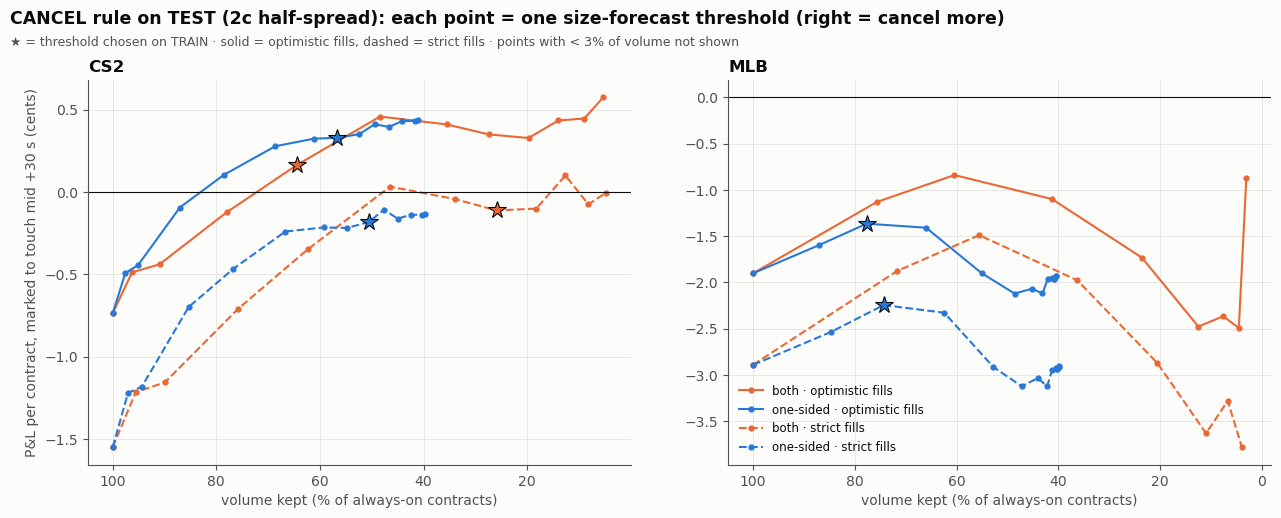

,sport,forecast fit,horizon,test trades,P&L per contract after fee (c),t (by match)
0,CS2,feed as received,10 s,11,-0.13,-0.44
1,CS2,feed as received,30 s,145,0.32,0.62
2,CS2,feed 2.5 s earlier,10 s,38,1.67,1.90
3,CS2,feed 2.5 s earlier,30 s,230,0.35,1.06
4,MLB,feed as received,10 s,6,-0.53,NaN
5,MLB,feed as received,30 s,0,NaN,NaN
6,MLB,feed 0.2 s earlier,10 s,6,-0.53,NaN
7,MLB,feed 0.2 s earlier,30 s,0,NaN,NaN


In [16]:
p5.cancel_frontier_figure(FILLS, FALL, CHOSEN, 2, f"{GR}/p5_cancel_frontier_2c.png")
rows = []
for s in SPORTS:
    for fit, sfx in (("feed as received", ""), (f"feed {K[s]:g} s earlier", "_k")):
        for h in (10, 30):
            T = p5.take_trades(G5[s], FALL[s].assign(**{f"dir{h}": FALL[s][f"dir{h}{sfx}"]}), CTX[s], h); T = T[T.test]
            v, t = p5.wmean_t(T.pnl_c.values / 100, np.ones(len(T)), T.match_id.values) if len(T) else (np.nan, np.nan)
            rows.append({"sport": s, "forecast fit": fit, "horizon": f"{h} s", "test trades": len(T), "P&L per contract after fee (c)": v, "t (by match)": t})
TAKE = pd.DataFrame(rows); TAKE.to_csv(f"{OUT}/p5_take.csv", index=False)
del X5
TAKE.round(2)

**Result (test)**
- **Forecasts:** direction R² is about **3% (CS2)** and **0.5% (MLB)**, the single digits the README predicts. BETER 2.5 s earlier adds about half a point. Size is far more predictable (8–16%): late, close, near-50% states roughly double the move.
- **Placebo:** features 60 s stale score R² ≈ 0.
- **CANCEL:**
  - **CS2:** it works. Avoided fills lose 2–8c each, and the maker goes from significantly negative to about break-even at 2–3c half-spreads.
  - **MLB:** it never breaks even.
- **TAKE:** CS2 is positive but not significant. MLB: none.

**Compromise:** the CANCEL/TAKE simulations use `mm_core`'s fill bounds (optimistic / strict) and ignore the real book. Part 6 adds the real queue.

## Part 6: make markets against the real touch

**Queue model:**
- **The README's priority rule:** improve the touch to be first in line; join it to sit behind the displayed size; behind it, not fillable.
- **Our stated drain model:** prints at our price eat the queue ahead first; the queue ahead shrinks if the displayed size drops below it; a print through our price fills us; any price change sends us to the back.
- **Timing:** decisions once a second, live 0.1 s later.
- **Placement:** post-only and pennying (at most one tick inside the touch).

**Half-spreads:** 1–3c, plus "join the touch" (≈ 0.5c, an extra beyond the README), because MLB's touch is one tick.

**Versions, identical except for information**
- **tape only;**
- **feed as received;**
- **feed k s earlier;**
- **Part 5 model** (size cancel + direction skew).

**Key decisions, all on train**
- **Fair value:** chosen by mean train P&L across half-spreads.
- **Components:** added greedily, kept only if they raise train P&L per contract while keeping ≥ 60% of volume. The floor stops "cancel everything" from winning by default.

**Reporting**
- **The frontier** varies the post size (CS2 10–200, MLB 50–2,000).
- **Break-even volume** is read off the upper envelope; CIs from a paired match bootstrap.
- **Volume** is a share of in-play volume for CS2 and contracts for MLB.

In [17]:
Dg = {s: p6.decision_grid(CTX[s], FALL[s]) for s in SPORTS}
SIM = {s: p6.Sim(CTX[s], Dg[s], s) for s in SPORTS}
FD = {(s, k): p6.feed_columns(Dg[s], s, k, EV) for s in SPORTS for k in (0.0, K[s])}
Q0 = {"CS2": 50, "MLB": 500}; H_ALL = ["join", 1, 2, 3]
train_pnl = lambda s, wb, wa: SIM[s].summary(SIM[s].run(wb, wa, Q0[s]), "train")
rows = []
for s in SPORTS:
    for fair in ("mtape", "micro"):
        for place in ("naive", "penny"):
            for h in H_ALL:
                if h == "join" and place == "naive": continue
                r = train_pnl(s, *p6.policy_quotes(Dg[s], Dg[s][fair].values, h, place))
                rows.append({"sport": s, "fair": fair, "placement": place, "h": str(h), "train_pnl_c": r["pnl30_c"], "train_share_pct": r["share_pct"]})
S1 = pd.DataFrame(rows)
fair_pick = S1[S1.placement == "penny"].groupby(["sport", "fair"]).train_pnl_c.mean().unstack()
assert {s: fair_pick.loc[s].idxmax() for s in SPORTS} == p6.FAIR, "train choice of fair value changed"
S1.pivot_table(index=["sport", "fair", "placement"], columns="h", values="train_pnl_c", sort=False).round(2)

h                         1     2     3  join
sport fair  placement                        
CS2   mtape naive     -0.83 -1.30 -1.75   NaN
            penny     -0.60 -1.02 -1.44 -0.23
      micro naive     -0.64 -0.69 -1.05   NaN
            penny     -0.36 -0.50 -0.91 -0.21
MLB   mtape naive     -1.97 -3.66 -5.24   NaN
            penny     -1.84 -3.48 -4.98 -0.53
      micro naive     -2.82 -4.11 -5.82   NaN
            penny     -2.66 -3.96 -5.71 -0.52

In [18]:
score_fn = lambda s, v: (lambda prm: (lambda r: (r["pnl30_c"], r["share_pct"]))(train_pnl(s, *p6.version_quotes(s, v, "join", {s: prm}, Dg[s], FD, K))))
PARAMS, LOG = {}, []
for s in SPORTS:
    feed_opts = ([("BETER blend", [{"w_beter": w} for w in (0.17, 0.35, 0.5)]), ("pull while BETER suspended", [{"pull_suspended": True}])] if s == "CS2" else
                 [("pull after pitch release", [{"pitch_window": w} for w in (4, 6, 8, 10)]), ("pull during Betstop", [{"pull_betstop": True}])])
    p_feed, log = p6.greedy_select(score_fn(s, "feed as received"), {}, feed_opts); LOG += [(s, "feed", *x) for x in log]
    model_opts = [("size CANCEL", [{"size_q": q, "one_sided": o} for q in (0.7, 0.8, 0.9) for o in (True, False)]),
                  ("direction skew", [{"beta": b} for b in (0.5, 1.0, 2.0)])]
    PARAMS[s], log = p6.greedy_select(score_fn(s, "Part 5 model"), p_feed, model_opts); LOG += [(s, "Part 5 model", *x) for x in log]
assert PARAMS == json.load(open("output/part6_params.json")), "train selection changed"
json.dump(PARAMS, open(f"{OUT}/p6_params.json", "w"), indent=1)
pd.DataFrame(LOG, columns=["sport", "version", "step", "components", "train P&L +30s (c)", "train volume (%)"]).round(3)

,sport,version,step,components,train P&L +30s (c),train volume (%)
0,CS2,feed,start,{},-0.206,7.725
1,CS2,feed,BETER blend,{'w_beter': 0.35},0.166,5.745
2,CS2,feed,pull while BETER suspended,"{'w_beter': 0.35, 'pull_suspended': True}",0.351,4.554
3,CS2,Part 5 model,start,"{'w_beter': 0.35, 'pull_suspended': True}",0.351,4.554
4,CS2,Part 5 model,size CANCEL,"{'w_beter': 0.35, 'pull_suspended': True, 'size_q': 0.7, 'one_sided': True}",0.558,3.428
5,CS2,Part 5 model,direction skew,"{'w_beter': 0.35, 'pull_suspended': True, 'size_q': 0.7, 'one_sided': True, 'beta': 2.0}",0.584,3.141
6,MLB,feed,start,{},-0.528,3.843
7,MLB,feed,pull after pitch release,{},-0.528,3.843
8,MLB,feed,pull during Betstop,{'pull_betstop': True},-0.418,3.262
9,MLB,Part 5 model,start,{'pull_betstop': True},-0.418,3.262


In [19]:
rows, QT = [], []
for s in SPORTS:
    for v in p6.VERSIONS:
        for h in H_ALL:
            wb, wa, wb0, wa0 = p6.version_quotes(s, v, h, PARAMS, Dg[s], FD, K, return_masks=True)
            r = SIM[s].summary(SIM[s].run(wb, wa, Q0[s]), "test")
            rows.append({"sport": s, "version": v, "h": "join (≈0.5c)" if h == "join" else f"{h}c", "volume (share)": f"{r['share_pct']:.2f}%",
                         "contracts": f"{r['contracts']:,.0f}", "P&L +30 s (c)": f"{r['pnl30_c']:+.2f} (t {r['pnl30_t']:+.1f})",
                         "+120 s": f"{r['pnl120_c']:+.2f} (t {r['pnl120_t']:+.1f})", "settle": f"{r['pnl_settle_c']:+.2f} (t {r['pnl_settle_t']:+.1f})"})
            if h in ("join", 1): QT.append({"sport": s, "version": v, "h": rows[-1]["h"], **p6.quote_time_row(Dg[s], wb, wa, wb0, wa0, p6.FAIR[s])})
TV = pd.DataFrame(rows); TV.to_csv(f"{OUT}/p6_test_versions.csv", index=False)
display(TV.set_index(["sport", "version", "h"]))
QT = pd.DataFrame(QT); QT.to_csv(f"{OUT}/p6_quote_time.csv", index=False)
QT.style.format({c: "{:.1%}" for c in QT.columns[3:]}).hide(axis="index")

volume (share)  contracts   P&L +30 s (c)  \
sport version          h                                                        
CS2   tape only        join (≈0.5c)         10.64%    238,447  -0.20 (t -1.7)   
                       1c                    5.80%    129,943  -0.28 (t -1.7)   
                       2c                    2.41%     53,904  -0.67 (t -2.9)   
                       3c                    1.05%     23,421  -0.83 (t -2.0)   
      feed as received join (≈0.5c)          5.43%    121,672  +0.26 (t +1.4)   
                       1c                    4.64%    104,096  +0.07 (t +0.3)   
                       2c                    2.47%     55,322  +0.12 (t +0.4)   
                       3c                    1.34%     30,083  +0.10 (t +0.2)   
      feed k s earlier join (≈0.5c)          5.36%    120,029  +0.37 (t +2.1)   
                       1c                    4.60%    102,997  +0.20 (t +1.0)   
                       2c                    2.42%     54,224  +0.33 (t +1.2)   
                       3c                    1.30%     29,146  +0.38 (t +1.0)   
      Part 5 model     join (≈0.5c)          3.83%     85,847  +0.46 (t +2.6)   
                       1c                    4.20%     94,096  +0.18 (t +1.1)   
                       2c                    2.78%     62,319  +0.34 (t +1.6)   
                       3c                    1.65%     37,035  +0.33 (t +1.2)   
MLB   tape only        join (≈0.5c)          3.99%  4,858,931  -0.14 (t -3.1)   
                       1c                    0.83%  1,011,795  -1.31 (t -4.4)   
                       2c                    0.31%    372,330  -2.79 (t -4.4)   
                       3c                    0.15%    185,334  -4.82 (t -4.6)   
      feed as received join (≈0.5c)          3.44%  4,196,079  -0.07 (t -1.4)   
                       1c                    0.57%    693,360  -1.18 (t -3.7)   
                       2c                    0.19%    228,426  -2.92 (t -4.1)   
                       3c                    0.09%    108,596  -5.05 (t -4.3)   
      feed k s earlier join (≈0.5c)          3.45%  4,199,904  -0.06 (t -1.2)   
                       1c                    0.57%    688,949  -1.11 (t -3.4)   
                       2c                    0.18%    225,105  -2.81 (t -4.0)   
                       3c                    0.09%    105,711  -4.88 (t -4.2)   
      Part 5 model     join (≈0.5c)          2.03%  2,475,702  -0.04 (t -0.8)   
                       1c                    0.14%    170,964  -1.36 (t -3.1)   
                       2c                    0.03%     40,335  -4.40 (t -3.2)   
                       3c                    0.02%     18,907  -6.74 (t -3.4)   

                                             +120 s           settle  
sport version          h                                              
CS2   tape only        join (≈0.5c)  -0.51 (t -2.0)   +2.18 (t +2.2)  
                       1c            -0.50 (t -2.0)   +2.29 (t +1.4)  
                       2c            -0.91 (t -2.2)   -0.19 (t -0.1)  
                       3c            -1.52 (t -1.4)   +0.78 (t +0.3)  
      feed as received join (≈0.5c)  +0.57 (t +2.1)   +4.13 (t +1.7)  
                       1c            +0.63 (t +2.1)   +5.53 (t +1.6)  
                       2c            +1.19 (t +2.9)   +9.16 (t +1.8)  
                       3c            +1.72 (t +2.7)  +12.46 (t +1.7)  
      feed k s earlier join (≈0.5c)  +0.72 (t +3.1)   +4.39 (t +1.8)  
                       1c            +0.82 (t +3.0)   +6.01 (t +1.7)  
                       2c            +1.51 (t +4.5)  +10.16 (t +2.0)  
                       3c            +2.10 (t +3.6)  +13.30 (t +1.9)  
      Part 5 model     join (≈0.5c)  +1.09 (t +4.7)   +6.43 (t +2.1)  
                       1c            +0.83 (t +3.5)   +6.77 (t +1.9)  
                       2c            +1.27 (t +4.1)   +8.60 (t +1.9)  
                       3c            +1.72 (t +3.9)  +13.48 (t +2.2)  
MLB

sport,version,h,quoting both sides,quoting one side,quoting neither,any side pulled by a rule,fillable (on or inside the touch),no usable touch / price < 3% or > 97%
CS2,tape only,join (≈0.5c),63.7%,0.0%,36.3%,0.0%,63.7%,36.3%
CS2,tape only,1c,63.7%,0.0%,36.3%,0.0%,47.6%,36.3%
CS2,feed as received,join (≈0.5c),30.8%,19.4%,49.7%,13.4%,50.3%,36.3%
CS2,feed as received,1c,50.3%,0.0%,49.7%,13.4%,45.0%,36.3%
CS2,feed k s earlier,join (≈0.5c),30.7%,19.5%,49.8%,13.4%,50.2%,36.3%
CS2,feed k s earlier,1c,50.2%,0.0%,49.8%,13.4%,45.0%,36.3%
CS2,Part 5 model,join (≈0.5c),15.4%,34.3%,50.3%,21.3%,49.7%,36.3%
CS2,Part 5 model,1c,31.5%,18.8%,49.7%,31.9%,45.5%,36.3%
MLB,tape only,join (≈0.5c),69.8%,5.7%,24.5%,0.0%,75.5%,24.5%
MLB,tape only,1c,75.5%,0.0%,24.5%,0.0%,8.8%,24.5%


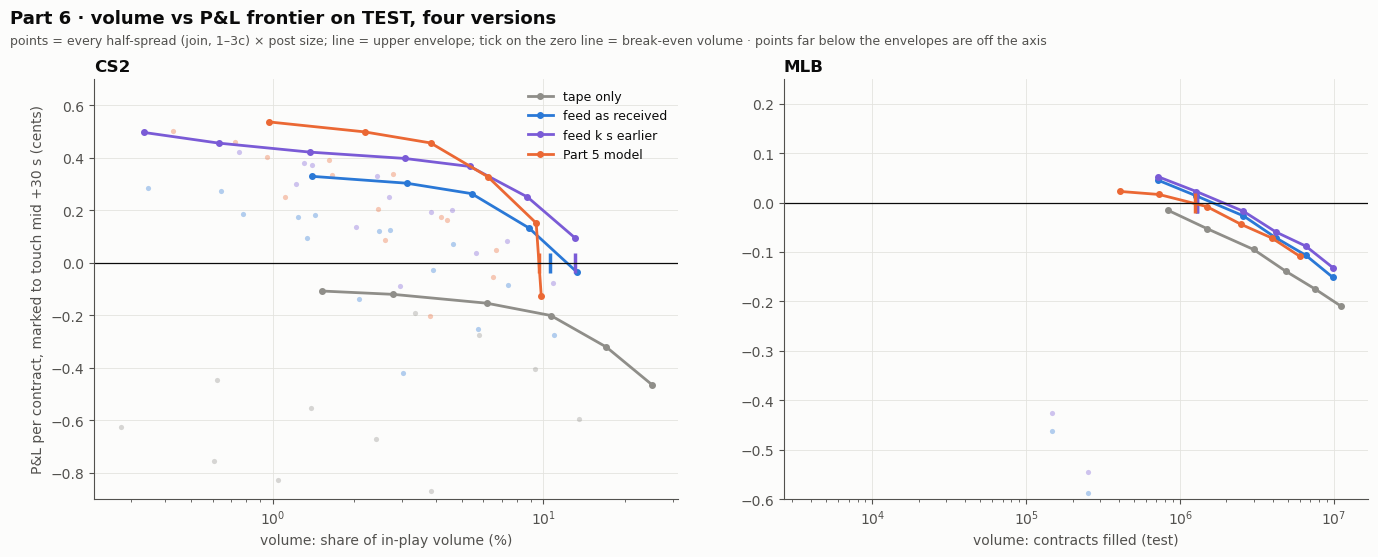

sport,version,break-even volume,95% CI,unit
CS2,tape only,0.00,"[0.00, 11.26]",% of in-play volume
CS2,feed as received,10.54,"[1.64, 15.84]",% of in-play volume
CS2,feed k s earlier,13.07,"[5.30, 16.08]",% of in-play volume
CS2,Part 5 model,9.62,"[4.39, 12.36]",% of in-play volume
MLB,tape only,0.00,"[0.00, 1,947,172.44]",contracts
MLB,feed as received,"1,278,718.49","[0.00, 7,999,404.33]",contracts
MLB,feed k s earlier,"1,278,150.63","[0.00, 10,288,379.51]",contracts
MLB,Part 5 model,"1,243,302.69","[0.00, 5,966,171.88]",contracts


sport,headline,extra break-even volume,95% CI (paired),share of bootstraps > 0
CS2,feed as received − tape only,+10.54 pp of in-play volume,"[+0.00, +15.12]",97%
CS2,faster feed − feed as received,+2.53 pp of in-play volume,"[-0.26, +5.09]",56%
CS2,Part 5 model − feed as received,-0.92 pp of in-play volume,"[-4.20, +3.74]",30%
MLB,feed as received − tape only,"+1,278,718.49 contracts","[+0.00, +6,246,143.09]",81%
MLB,faster feed − feed as received,-567.86 contracts,"[-20,345.73, +2,327,499.35]",80%
MLB,Part 5 model − feed as received,"-35,415.80 contracts","[-5,478,896.52, +3,092,055.30]",37%


In [20]:
QS = {"CS2": [10, 25, 50, 100, 200], "MLB": [50, 100, 250, 500, 1000, 2000]}
FRs, BE, HEAD = [], [], []
for s in SPORTS:
    mids = sorted(CTX[s]["test"] & set(Dg[s].match_id)); vol_m = SIM[s].vol.reindex(mids).fillna(0).values
    FR, PM = p6.frontier_points(SIM[s], lambda v, h: p6.version_quotes(s, v, h, PARAMS, Dg[s], FD, K), p6.VERSIONS, H_ALL, QS[s], mids)
    FRs.append(FR.assign(sport=s))
    point, boot = p6.bootstrap_break_even(FR, PM, vol_m, "share" if s == "CS2" else "contracts", p6.VERSIONS)
    unit = "pp of in-play volume" if s == "CS2" else "contracts"
    for v in p6.VERSIONS:
        BE.append({"sport": s, "version": v, "break-even volume": point[v], "95% CI": f"[{np.percentile(boot[v], 2.5):,.2f}, {np.percentile(boot[v], 97.5):,.2f}]",
                   "unit": "% of in-play volume" if s == "CS2" else "contracts"})
    for name, a, b in [("feed as received − tape only", "feed as received", "tape only"), ("faster feed − feed as received", "feed k s earlier", "feed as received"),
                       ("Part 5 model − feed as received", "Part 5 model", "feed as received")]:
        dlt = boot[a] - boot[b]
        HEAD.append({"sport": s, "headline": name, "extra break-even volume": f"{point[a] - point[b]:+,.2f} {unit}",
                     "95% CI (paired)": f"[{np.percentile(dlt, 2.5):+,.2f}, {np.percentile(dlt, 97.5):+,.2f}]", "share of bootstraps > 0": f"{(dlt > 0).mean():.0%}"})
FR_ALL, BE, HEAD = pd.concat(FRs, ignore_index=True), pd.DataFrame(BE), pd.DataFrame(HEAD)
FR_ALL.to_csv(f"{OUT}/p6_frontier.csv", index=False); BE.to_csv(f"{OUT}/p6_breakeven.csv", index=False); HEAD.to_csv(f"{OUT}/p6_headline.csv", index=False)
p6.frontier_figure(FR_ALL, BE, f"{GR}/p6_frontier.png")
display(BE.style.format({"break-even volume": "{:,.2f}"}).hide(axis="index"))
HEAD.style.hide(axis="index")

In [21]:
# robustness to the stated compromise: "join the touch" P&L at +30 s with the strict 5 s touch rule for the marks
rows = []
for s in SPORTS:
    for v in p6.VERSIONS:
        Fl = SIM[s].run(*p6.version_quotes(s, v, "join", PARAMS, Dg[s], FD, K), Q0[s]); te = Fl[Fl.test]
        m5 = te.side.values * (p3.touch_mid_at(CTX[s]["bb"], te.match_id.values, te.t.values + 30, max_stale_s=5.0) - te.price_c.values / 100)
        a, b = p5.wmean_t(te.pnl30.values, te["size"].values, te.match_id.values), p5.wmean_t(m5, te["size"].values, te.match_id.values)
        rows.append({"sport": s, "version": v, "P&L +30 s, mark ≤30 s old": f"{a[0]:+.2f} (t {a[1]:+.1f})", "P&L +30 s, mark ≤5 s old": f"{b[0]:+.2f} (t {b[1]:+.1f})",
                     "fills with a ≤5 s mark": f"{np.isfinite(m5).mean():.0%}"})
pd.DataFrame(rows)

,sport,version,"P&L +30 s, mark ≤30 s old","P&L +30 s, mark ≤5 s old",fills with a ≤5 s mark
0,CS2,tape only,-0.20 (t -1.7),-0.21 (t -1.6),88%
1,CS2,feed as received,+0.26 (t +1.4),+0.26 (t +1.3),87%
2,CS2,feed k s earlier,+0.37 (t +2.1),+0.38 (t +2.1),86%
3,CS2,Part 5 model,+0.46 (t +2.6),+0.45 (t +2.3),86%
4,MLB,tape only,-0.14 (t -3.1),-0.14 (t -3.0),99%
5,MLB,feed as received,-0.07 (t -1.4),-0.07 (t -1.3),99%
6,MLB,feed k s earlier,-0.06 (t -1.2),-0.06 (t -1.1),99%
7,MLB,Part 5 model,-0.04 (t -0.8),-0.05 (t -0.9),99%


**Result (test)**
- **The queue rule decides everything.** Quotes behind the touch are only filled when the market runs into them, so wider half-spreads lose *more*. The best half-spread is **join the touch**.
- **CS2:** tape only can't break even. With BETER (blend 0.35 + pull while suspended) the maker is positive at every half-spread.
  - **The feed adds about +10.5 pp of in-play volume at break-even** (paired CI 0 to +15 pp; positive in 97% of resamples).
  - **A 2.5 s faster BETER** adds about **+2.5 pp**, which is not distinguishable from zero.
  - **The Part 5 forecasts** raise P&L per contract (+0.46c, t 2.6) at lower volume.
- **MLB: none.** On the touch every version is within a few hundredths of a cent of zero, and clearly negative elsewhere.
- **Strict 5 s marks:** they tell the same story.

**Interpretation and caveats**
- **P&L per contract is a 30 s markout:** spread captured net of adverse selection. It ranks policies; it isn't realized profit.
- **Settlement P&L** mixes in unhedged inventory (no inventory limit helped on train) and is noisy.
- **The frontier** is read on test across post sizes, so treat the break-even volumes as upper-end estimates.
- **Many results have |t| < 2** on three test days, and we say so.